# House Price Prediction Using Machine Learning

## Project Objective

This project predicts house prices using different regression models.

Multiple machine learning algorithms are tested and compared
to find the best performing model for price prediction.

In [3]:
import pandas as pd
import seaborn as sns

In [4]:
df = pd.read_csv('Housing.csv')
df.shape

(545, 13)

In [5]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
df.isnull().sum() # no null values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
df.duplicated().sum() # no dupes

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: xlabel='area', ylabel='price'>

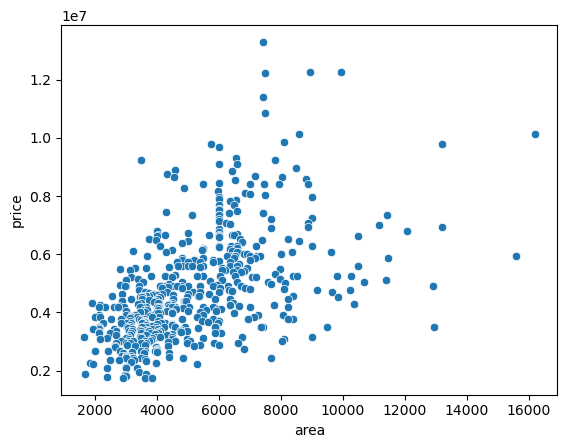

In [10]:
sns.scatterplot(x = df['area'], y = df['price'])

<Axes: xlabel='area', ylabel='price'>

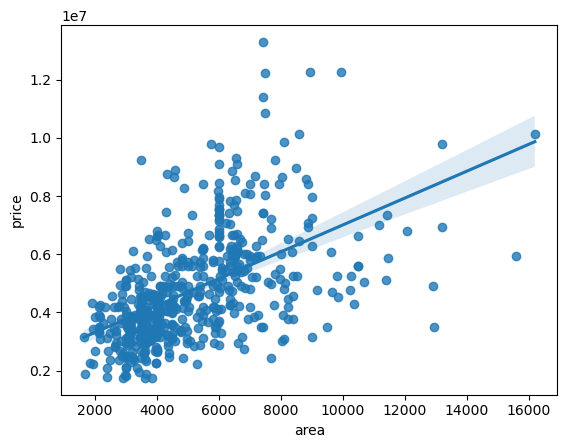

In [11]:
sns.regplot(x = df['area'], y = df['price'])
# On average, price increases as area increases.

In [12]:
# Observation:
# The scatter plot shows that house price generally increases with area.
# The regression line also shows a positive relationship between area and price.
# but, the spread of points indicates that other factors also influence price as well.

<Axes: xlabel='bedrooms', ylabel='price'>

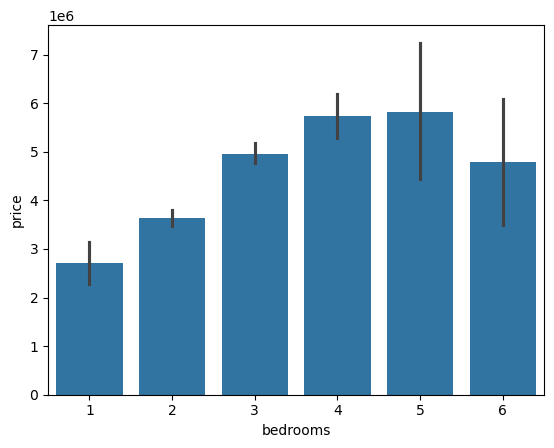

In [13]:
sns.barplot(x = df['bedrooms'], y = df['price'])

In [14]:
# Average house price generally increases with the number of bedrooms as is seen in the above barplot.
# Houses with 4 to 5 bedrooms are most expensive of the lot.
# also variation at 5, 6 bedroom shows bedroom count alone does not determine price

### Train–test split:

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [16]:
X = df[['area','bedrooms','bathrooms','stories','parking']] # features
X

,area,bedrooms,bathrooms,stories,parking
0,7420,4,2,3,2
1,8960,4,4,4,3
2,9960,3,2,2,2
3,7500,4,2,2,3
4,7420,4,1,2,2
...,...,...,...,...,...
540,3000,2,1,1,2
541,2400,3,1,1,0
542,3620,2,1,1,0
543,2910,3,1,1,0


In [17]:
y = df['price'] # target
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

#### Training Linear Regression model: 

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [20]:
# Making predictions
y_pred = model.predict(X_test)

In [21]:
X_test

,area,bedrooms,bathrooms,stories,parking
316,5900,4,2,2,1
77,6500,3,2,3,0
360,4040,2,1,1,0
90,5000,3,1,2,0
493,3960,3,1,1,0
...,...,...,...,...,...
15,6000,4,1,2,2
357,6930,4,1,2,1
39,6000,4,2,4,1
54,6000,3,2,2,1


In [22]:
y_pred

array([6178627.50326817, 6370140.85865473, 3283148.1570249 ,
       4226007.94816032, 3409685.55116741, 4262158.3499693 ,
       5493440.53152357, 5559897.74293016, 3373715.42245305,
       3020513.18649699, 9519985.01490602, 3250408.25967961,
       3184310.73107686, 3639160.7315938 , 3907874.98339005,
       6174323.64572264, 3148160.32926787, 4872535.73454622,
       4826205.69113307, 3888527.39095668, 5222386.81260559,
       4294589.3803585 , 3162381.17719464, 4193028.43115341,
       5747707.28367817, 7619041.42465273, 2989724.54874164,
       4794005.74968623, 7434038.64867549, 3457027.28535551,
       5102872.70577387, 3982998.90101381, 6215707.38061091,
       4724828.08224186, 4307759.63367012, 5625853.70972471,
       4791990.70630181, 3815116.83871033, 3261429.41224535,
       4879463.83866908, 5326652.37523625, 3156512.70502897,
       6345431.50216772, 4316575.21358846, 4120177.60802241,
       4190668.52130486, 6710808.14327267, 4603723.42489655,
       4521704.65093634,

### Evaluating model performance

In [23]:
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 2292721545725.362
RMSE: 1514173.5520492233
R² Score: 0.5464062355495872


In [25]:
# Observation:
# The model achieved an R2 score of around 0.55, which indicates moderate performance.

### Converting categorical variables into numeric format using one-hot encoding


In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [27]:
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,False,False,False,False,False,False,False,False


In [28]:
df_encoded = df_encoded.astype(int) # converting to numeric since model undestands that
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [29]:
X = df_encoded[['area','bedrooms','bathrooms','stories','parking','mainroad_yes','guestroom_yes','basement_yes','hotwaterheating_yes','furnishingstatus_unfurnished']] # features
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,0
1,8960,4,4,4,3,1,0,0,0,0
2,9960,3,2,2,2,1,0,1,0,0
3,7500,4,2,2,3,1,0,1,0,0
4,7420,4,1,2,2,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,0,1
541,2400,3,1,1,0,0,0,0,0,0
542,3620,2,1,1,0,1,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0


In [30]:
y = df_encoded['price'] # target
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [33]:
y_pred = model.predict(X_test)

In [34]:
X_test

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,furnishingstatus_unfurnished
316,5900,4,2,2,1,0,0,1,0,1
77,6500,3,2,3,0,1,0,0,0,0
360,4040,2,1,1,0,1,0,0,0,0
90,5000,3,1,2,0,1,0,0,0,0
493,3960,3,1,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
15,6000,4,1,2,2,1,0,1,0,0
357,6930,4,1,2,1,0,0,0,0,0
39,6000,4,2,4,1,1,0,0,0,0
54,6000,3,2,2,1,1,1,0,0,0


In [35]:
y_pred

array([5632303.67161442, 6247969.17494405, 3293068.62073861,
       4198648.18066212, 3371507.87907691, 3774719.41665066,
       5187286.88438215, 6305050.11618327, 2826548.44598095,
       2509421.76504953, 9125004.23961778, 2912536.30757915,
       2336492.08743416, 3737054.72812728, 4140945.14671738,
       5484635.35343218, 3277944.0722686 , 4404960.26172514,
       4939449.60390828, 3829055.34350103, 4938050.52359258,
       5067410.67100776, 2834599.46268768, 4715774.91549699,
       5973355.45644761, 7795708.85607611, 3594166.26546623,
       5660543.24758058, 7585339.83390027, 3551406.68592289,
       5597082.19165486, 3617387.93440077, 6448161.53769692,
       4640290.3017138 , 3885890.08390844, 5470045.76913698,
       5583064.30628146, 4025225.94936113, 2371177.32758778,
       4790179.57449156, 5039617.07300883, 2829403.67302825,
       6226092.16585171, 4264272.83325952, 4034152.30374175,
       3730456.61033951, 6653977.05150164, 4484912.65069805,
       4038108.42538022,

In [36]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MSE: 2083133991435.404
RMSE: 1443306.617263083
R² Score: 0.5878711957884724


In [37]:
model.score(X_test,y_test) ## Returns R²

0.5878711957884724

### Observation:
#### After encoding categorical features, model performance improved.
#### R2 score increased and RMSE decreased compared to the basic model.
#### This shows that additional features help in better price prediction.

### # Training Random Forest Regressor to compare with Linear Regression:

In [38]:
from sklearn.ensemble import RandomForestRegressor

In [39]:
# Initialize the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,          # limit depth
    min_samples_leaf=5,   # prevent tiny leaves
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 1468764.8793701553
Random Forest R²: 0.5732040182001867


In [40]:
model.score(X_test,y_test) ## Returns R²

0.5878711957884724

### Observation:
#### Random Forest did not outperform Linear Regression in this case.
#### The R2 score is slightly lower and RMSE is slightly higher.
#### This suggests that the relationship in the data is mostly linear.


### # Training Ridge Regression

In [41]:
from sklearn.linear_model import Ridge

In [42]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # you can tune alpha later

In [44]:
# Train the model
ridge_model.fit(X_train, y_train)

Ridge()

In [45]:
# Predict on test set
y_pred = ridge_model.predict(X_test)

In [46]:
import numpy as np

In [47]:
# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge RMSE:", rmse)
print("Ridge R²:", r2)

Ridge RMSE: 1443342.5679561426
Ridge R²: 0.5878506644606303


### Model Comparison Summary:
#### Linear Regression and Ridge Regression performed best.
#### Random Forest did not improve results in this case.
#### This suggests that the relationship between features and price is mostly linear.

<Axes: xlabel='area', ylabel='Count'>

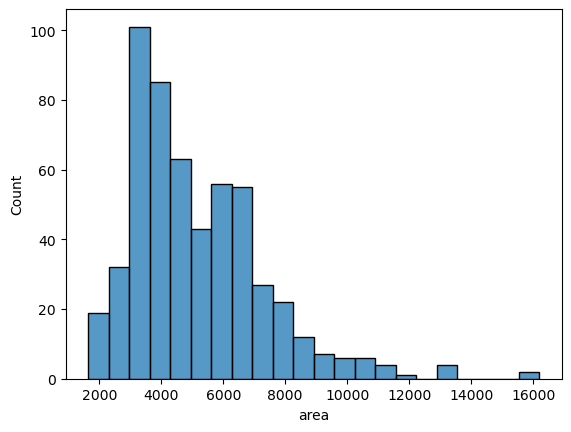

In [48]:
sns.histplot(df['area'])
# The distribution is slightly right-skewed.

### Feature Engineering & Retraining the model with Newly Added Features:

In [49]:
import numpy as np

In [50]:
# log1p(x) computes:
# log1p(x)=log(1+x)

# Why 1 + x?

# Avoids issues if x = 0 (since log(0) is undefined)

# Ensures even very small numbers work

# large numbers get compressed, and small numbers stay small.


# Why we do this:

# Compresses outliers (very large areas) → reduces their effect on models.

# Makes skewed distributions more symmetric, closer to normal.

# Helps linear models see relationships more clearly (linearizes exponential relationships).

# Safe for zero values because of log1p.

In [51]:
# Add log-transformed column('area'):-
df['log_area'] = np.log1p(df['area'])

In [52]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,log_area
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,8.912069
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,9.100637
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,9.206433
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,8.922792
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,8.912069


<Axes: xlabel='log_area', ylabel='Count'>

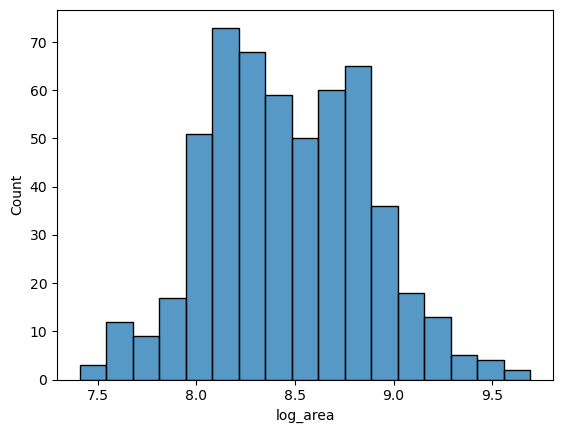

In [53]:
sns.histplot(df['log_area'])

## Conclusion , Skewness Decreased

In [54]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [55]:
df_encoded['log_area'] = np.log1p(df_encoded['area']) # added logArea

In [56]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069


In [57]:
df_encoded['room_interaction'] = df_encoded['bedrooms'] * df_encoded['bathrooms'] # feature engineered "room_interaction"

In [58]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area,room_interaction
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069,8
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637,16
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433,6
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792,8
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069,4


In [59]:
df_encoded['total_rooms'] = df_encoded['bedrooms'] + df_encoded['bathrooms']


In [60]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069,8,6
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637,16,8
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433,6,5
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792,8,6
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069,4,5


In [61]:
import numpy as np
df_encoded['log_price'] = np.log1p(df_encoded['price']) # to reduce skewness of price

In [62]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms,log_price
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069,8,6,16.403275
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637,16,8,16.321037
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433,6,5,16.321037
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792,8,6,16.318175
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069,4,5,16.250001


In [63]:
X = df_encoded[['area','bedrooms','bathrooms','stories','parking','mainroad_yes','guestroom_yes','furnishingstatus_unfurnished','log_area','room_interaction','total_rooms']] # features
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms
0,7420,4,2,3,2,1,0,0,8.912069,8,6
1,8960,4,4,4,3,1,0,0,9.100637,16,8
2,9960,3,2,2,2,1,0,0,9.206433,6,5
3,7500,4,2,2,3,1,0,0,8.922792,8,6
4,7420,4,1,2,2,1,1,0,8.912069,4,5
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,8.006701,2,3
541,2400,3,1,1,0,0,0,0,7.783641,3,4
542,3620,2,1,1,0,1,0,1,8.194506,2,3
543,2910,3,1,1,0,0,0,0,7.976252,3,4


In [64]:
y = df_encoded['price'] # target
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [65]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [66]:
# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)  # you can tune alpha later

In [67]:
# Train the model
ridge_model.fit(X_train, y_train)

Ridge()

In [68]:
# Predict on test set
y_pred = ridge_model.predict(X_test)

In [69]:
# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Ridge RMSE:", rmse)
print("Ridge R²:", r2)

Ridge RMSE: 1377247.5612136067
Ridge R²: 0.5595358731951903


In [70]:
df_encoded[['price']]

,price
0,13300000
1,12250000
2,12250000
3,12215000
4,11410000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [71]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms,log_price
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069,8,6,16.403275
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637,16,8,16.321037
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433,6,5,16.321037
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792,8,6,16.318175
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069,4,5,16.250001


In [72]:
df_encoded[['log_price']]

,log_price
0,16.403275
1,16.321037
2,16.321037
3,16.318175
4,16.250001
...,...
540,14.414348
541,14.384879
542,14.375127
543,14.375127


<Axes: xlabel='price', ylabel='Count'>

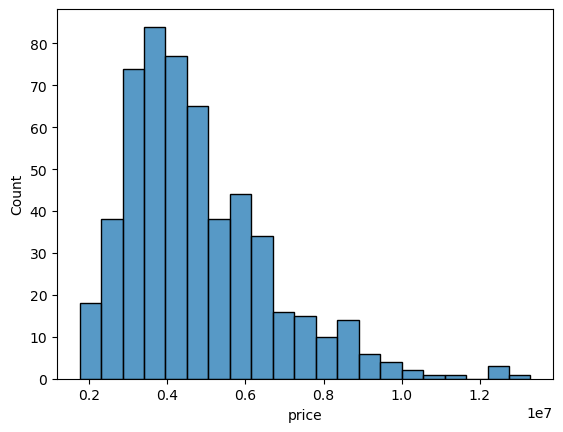

In [73]:
sns.histplot(x = df_encoded['price'])

<Axes: xlabel='log_price', ylabel='Count'>

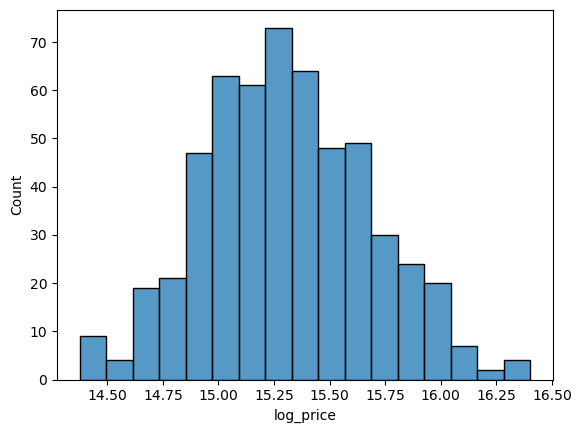

In [74]:
sns.histplot(x = df_encoded['log_price']) # less Skewed, using this as target y, to see model score

In [75]:
X = df_encoded[['area','bedrooms','bathrooms','stories','parking','mainroad_yes','guestroom_yes','furnishingstatus_unfurnished','log_area','room_interaction','total_rooms']] # features
X

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms
0,7420,4,2,3,2,1,0,0,8.912069,8,6
1,8960,4,4,4,3,1,0,0,9.100637,16,8
2,9960,3,2,2,2,1,0,0,9.206433,6,5
3,7500,4,2,2,3,1,0,0,8.922792,8,6
4,7420,4,1,2,2,1,1,0,8.912069,4,5
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,2,1,0,1,8.006701,2,3
541,2400,3,1,1,0,0,0,0,7.783641,3,4
542,3620,2,1,1,0,1,0,1,8.194506,2,3
543,2910,3,1,1,0,0,0,0,7.976252,3,4


In [76]:
y = np.log1p(df_encoded['price'])
y

0      16.403275
1      16.321037
2      16.321037
3      16.318175
4      16.250001
         ...    
540    14.414348
541    14.384879
542    14.375127
543    14.375127
544    14.375127
Name: price, Length: 545, dtype: float64

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

y_pred_log = ridge_model.predict(X_test)



In [78]:
y_test_price = np.expm1(y_test)
y_pred_price = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_test_price, y_pred_price))
r2 = r2_score(y_test_price, y_pred_price)


In [79]:
rmse

np.float64(1370980.715274891)

In [80]:
r2

0.5635352133306675

In [81]:
y.head()


0    16.403275
1    16.321037
2    16.321037
3    16.318175
4    16.250001
Name: price, dtype: float64

In [82]:
r2_log = r2_score(y_test, y_pred_log)
r2_price = r2_score(np.expm1(y_test), np.expm1(y_pred_log))

r2_log, r2_price


(0.5822354473503264, 0.5635352133306675)

In [83]:
df['price'].mean()

np.float64(4766729.247706422)

## Trying , Random Forest:

In [84]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,log_area,room_interaction,total_rooms,log_price
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0,8.912069,8,6,16.403275
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0,9.100637,16,8,16.321037
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0,9.206433,6,5,16.321037
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0,8.922792,8,6,16.318175
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0,8.912069,4,5,16.250001


In [85]:
X = df_encoded[['bedrooms','bathrooms','stories','parking','log_area','mainroad_yes','guestroom_yes','basement_yes','hotwaterheating_yes','airconditioning_yes','prefarea_yes','furnishingstatus_unfurnished']] # features
X

,bedrooms,bathrooms,stories,parking,log_area,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_unfurnished
0,4,2,3,2,8.912069,1,0,0,0,1,1,0
1,4,4,4,3,9.100637,1,0,0,0,1,0,0
2,3,2,2,2,9.206433,1,0,1,0,0,1,0
3,4,2,2,3,8.922792,1,0,1,0,1,1,0
4,4,1,2,2,8.912069,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,2,1,1,2,8.006701,1,0,1,0,0,0,1
541,3,1,1,0,7.783641,0,0,0,0,0,0,0
542,2,1,1,0,8.194506,1,0,0,0,0,0,1
543,3,1,1,0,7.976252,0,0,0,0,0,0,0


In [86]:
y = df_encoded['log_price'] # Target
y

0      16.403275
1      16.321037
2      16.321037
3      16.318175
4      16.250001
         ...    
540    14.414348
541    14.384879
542    14.375127
543    14.375127
544    14.375127
Name: log_price, Length: 545, dtype: float64

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [88]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


model.fit(X_train, y_train)


RandomForestRegressor(max_depth=15, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [89]:
pred = model.predict(X_test)


In [90]:
model.score(X_test,y_test) ## Returns R²

0.6341763470744394

### Observation:
#### Random Forest with log-transformed price performed the best so far.

### Final Model Comparison:
#### Linear Regression: R2 ~ 0.59
#### Ridge Regression: R2 ~ 0.59
#### Random Forest: R2 ~ 0.57
#### Random Forest (log price): R2 ~ 0.63 (Best)


In [91]:
import joblib

In [92]:
# Saving model:
joblib.dump(model, "house_price_model.pkl")

# Save feature names
joblib.dump(X.columns.tolist(), "model_features.pkl")

['model_features.pkl']